### Predictive Modeling with Multiple Linear Regression

Medical Readmission

Research Question: How successfully can we predict a patient's length of stay given that we know his or her medical conditions?

By Stephanie Nguyen

## Method Justification

Verify Assumptions:
1) Linearity: There exists a linear relationship between the independent variable, x, and the dependent variable, y.
2) Multicollinearity: Independent variables should not be highly correlated with each other.
3) Independence of Observations: The observations are independent and random.
4) Normality of Residuals: The residuals of the model are normally distributed.
5) Homoscedasticity: Homoscedasticity means that the error doesn't change across all the values of the independent variable. The residuals have a constant variance at every x.

Benefits:
Predictive modeling is a statistical method that helps with analyzing and understanding the relationship between two or more variables of interest.
Linear regression is a model building method used to explore causation in support of organizational decision making.

Multiple Linear Regression (MLR):
MLR is used since there are two or more independent variables and one dependent variable.


## Null Hypothesis
H<sub>0</sub>: $\beta$ = 0
## Alternative Hypothesis
H<sub>a</sub>: $\beta$ $ \neq $ 0

In [ ]:
# !pip install statsmodels
# !pip install scikit-learn

## Import libraries and packages 

In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Linear Regression 
from statsmodels.formula.api import ols

# Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Load Data
# import medical_clean.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\4. Linear Regression Modeling in Python\Data\medical_clean.csv")

# FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To opt-in to the future behavior, set
pd.set_option('future.no_silent_downcasting', True)

# Data Preparation

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

## Data Cleaning
Check for missing values, duplicates, and outliers

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

In [ ]:
# rename columns to provide more information on data provided
df_clean = df.rename(columns={"Item1": "Timely_admission","Item2": "Timely_treatment","Item3": "Timely_visits",
                   "Item4": "Reliability","Item5": "Options","Item6": "Hrs_of_treatment",
                   "Item7": "Courteous_staff","Item8": "Active_listening"})
df_clean.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Timely_admission,Timely_treatment,Timely_visits,Reliability,Options,Hrs_of_treatment,Courteous_staff,Active_listening
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# Find the number of unique values in each variable
for col in df_clean.columns:
    print(col, len(df_clean[col].unique()))

CaseOrder 10000
Customer_id 10000
Interaction 10000
UID 10000
City 6072
State 52
County 1607
Zip 8612
Lat 8588
Lng 8725
Population 5951
Area 3
TimeZone 26
Job 639
Children 11
Age 72
Income 9993
Marital 5
Gender 3
ReAdmis 2
VitD_levels 9976
Doc_visits 9
Full_meals_eaten 8
vitD_supp 6
Soft_drink 2
Initial_admin 3
HighBlood 2
Stroke 2
Complication_risk 3
Overweight 2
Arthritis 2
Diabetes 2
Hyperlipidemia 2
BackPain 2
Anxiety 2
Allergic_rhinitis 2
Reflux_esophagitis 2
Asthma 2
Services 4
Initial_days 9997
TotalCharge 9997
Additional_charges 9418
Timely_admission 8
Timely_treatment 7
Timely_visits 8
Reliability 7
Options 7
Hrs_of_treatment 7
Courteous_staff 7
Active_listening 7


### Remove variables with high cardinality

When dealing with categorical variables, only low cardinality can be accepted. Variables with high cardinality (5 levels or more) will be removed from the analysis.

In [ ]:
# List all variables and their data types with 5 levels or less
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        print(col, df_clean[col].dtype)

Area object
Marital object
Gender object
ReAdmis object
Soft_drink object
Initial_admin object
HighBlood object
Stroke object
Complication_risk object
Overweight object
Arthritis object
Diabetes object
Hyperlipidemia object
BackPain object
Anxiety object
Allergic_rhinitis object
Reflux_esophagitis object
Asthma object
Services object


In [ ]:
# Create a list of categorical variables with 5 or less levels
lst = []
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        lst.append(col)

print(lst)
print(len(lst))

['Area', 'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']
19


In [ ]:
# Remove patient demographic and unrelated variables from list
list_to_remove = ['Area','Marital','Gender','ReAdmis','Soft_drink', 'Initial_admin', 'Complication_risk', 'Services']

# Create list of independent variables (aka explanatory, predicting variables)
final_list = list(set(lst) - set(list_to_remove))
final_list.sort()

print(final_list)
print(len(final_list))


['Allergic_rhinitis', 'Anxiety', 'Arthritis', 'Asthma', 'BackPain', 'Diabetes', 'HighBlood', 'Hyperlipidemia', 'Overweight', 'Reflux_esophagitis', 'Stroke']
11


## Exploratory Data Analysis (EDA)

In [ ]:
# Descriptive Statistics - all explanatory variables
# Create a for loop to output the frequency for each explanatory variable
for var in final_list:
    print(df_clean[var].describe())

count     10000
unique        2
top          No
freq       6059
Name: Allergic_rhinitis, dtype: object
count     10000
unique        2
top          No
freq       6785
Name: Anxiety, dtype: object
count     10000
unique        2
top          No
freq       6426
Name: Arthritis, dtype: object
count     10000
unique        2
top          No
freq       7107
Name: Asthma, dtype: object
count     10000
unique        2
top          No
freq       5886
Name: BackPain, dtype: object
count     10000
unique        2
top          No
freq       7262
Name: Diabetes, dtype: object
count     10000
unique        2
top          No
freq       5910
Name: HighBlood, dtype: object
count     10000
unique        2
top          No
freq       6628
Name: Hyperlipidemia, dtype: object
count     10000
unique        2
top         Yes
freq       7094
Name: Overweight, dtype: object
count     10000
unique        2
top          No
freq       5865
Name: Reflux_esophagitis, dtype: object
count     10000
unique        2
to

In [ ]:
# Descriptive Statistics - dependent variable
print(df_clean['Initial_days'].describe())

count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64


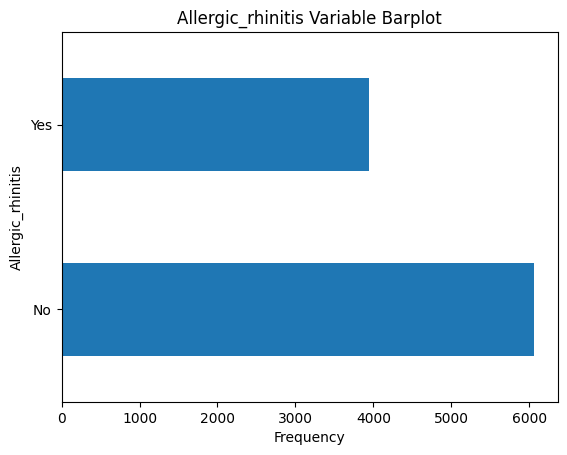

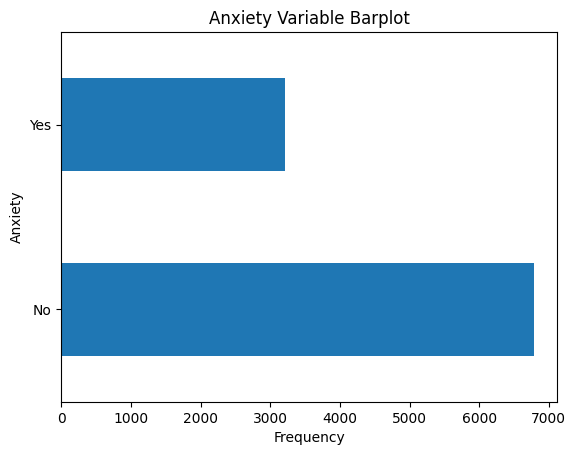

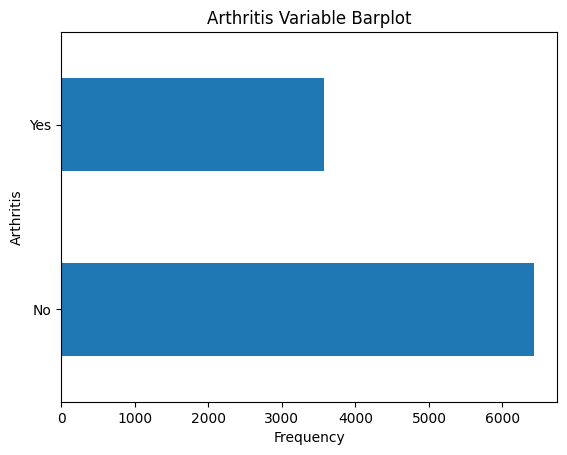

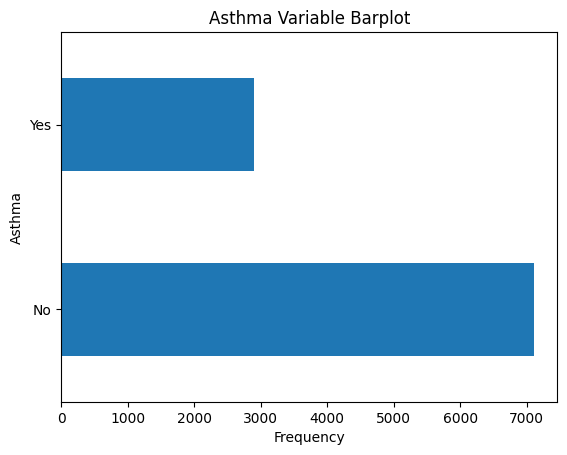

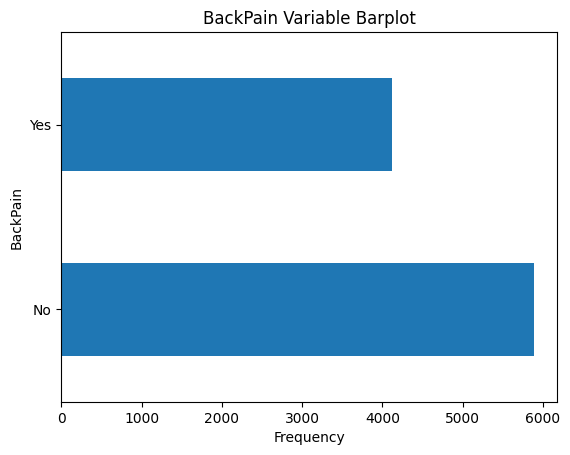

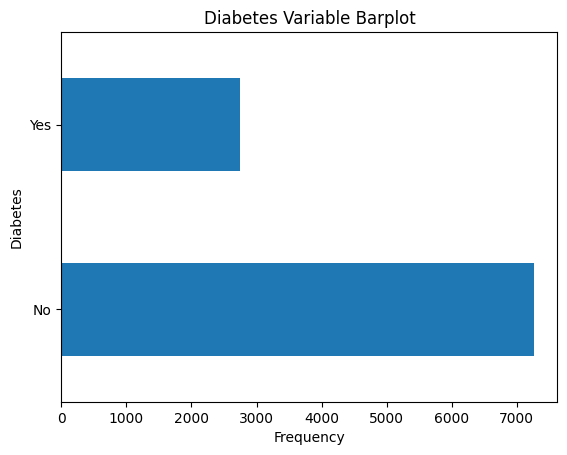

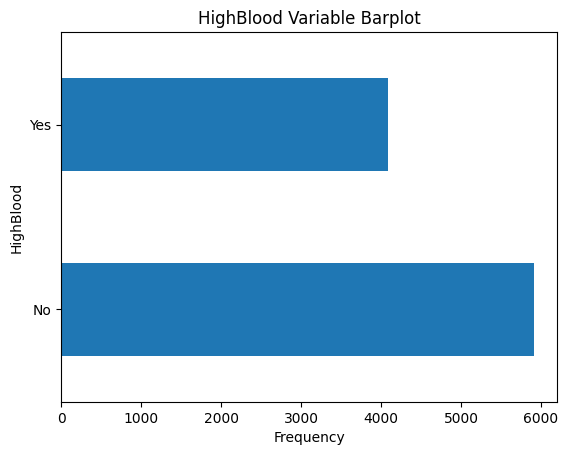

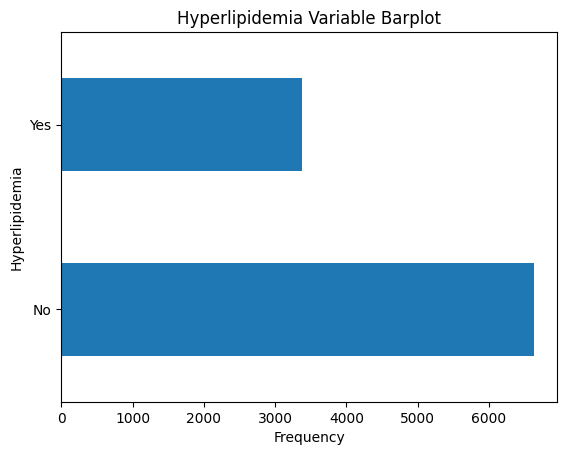

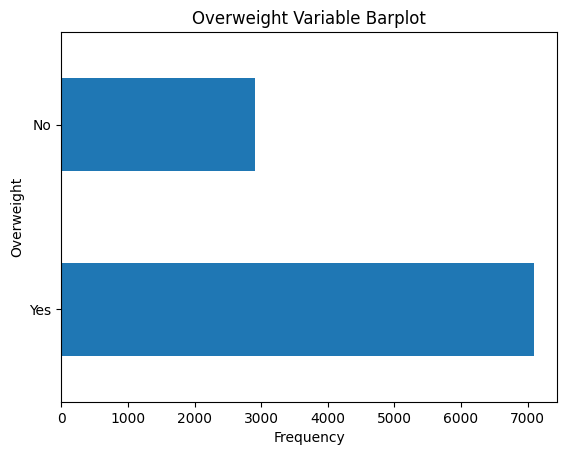

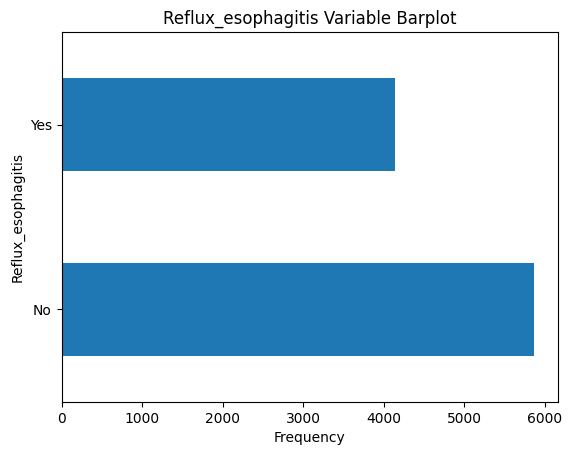

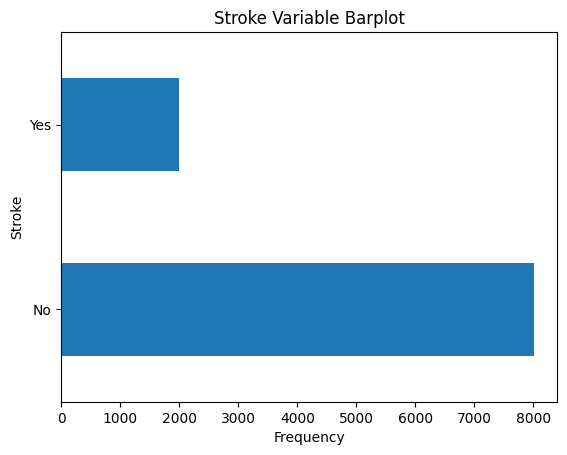

In [ ]:
# Univariate Analysis (visualization) - all explanatory variables
# Bar plots are used to represent categorical data and display frequency of the data.

# Create a loop to plot each explanatory variables on a horizontal bar plot
for var in final_list:
    df_clean[var].value_counts().plot(kind='barh')
    plt.title(var+' Variable Barplot')
    plt.xlabel('Frequency')
    plt.ylabel(var)
    plt.savefig(var+' Variable - Horizontal Barplot.png',bbox_inches='tight')
    plt.show()

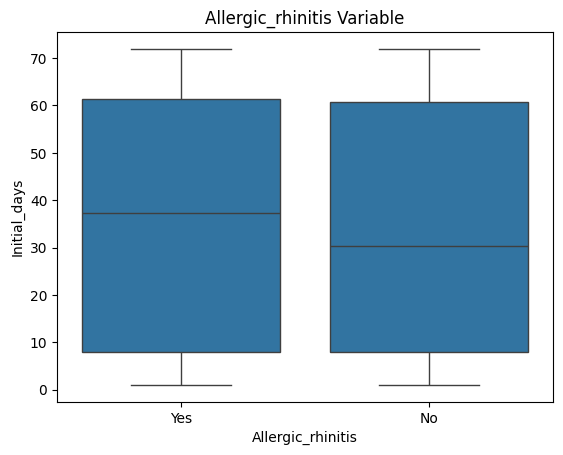

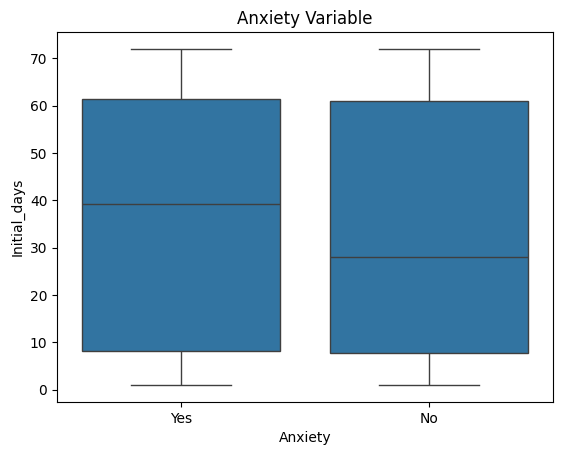

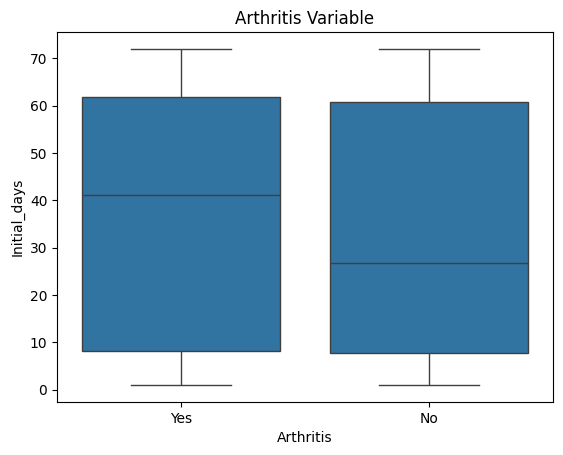

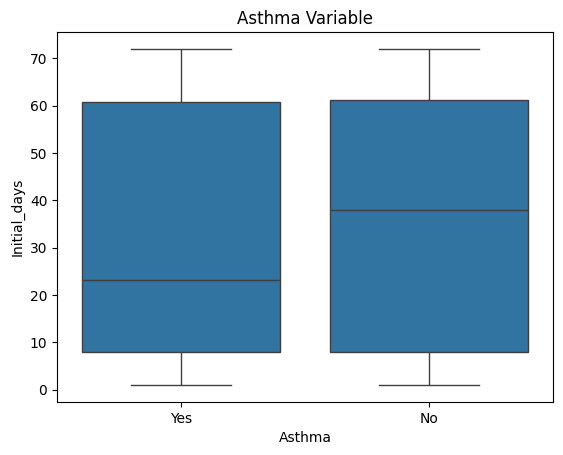

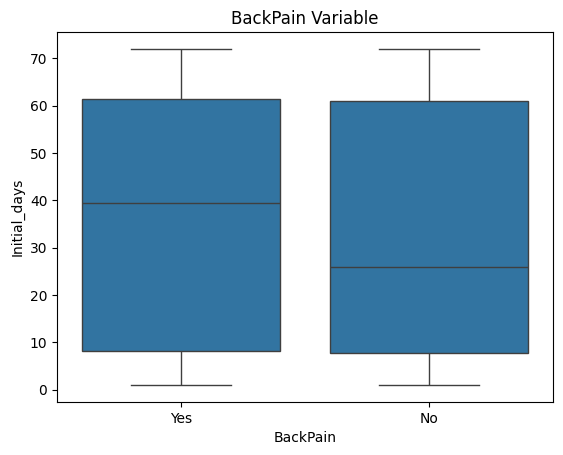

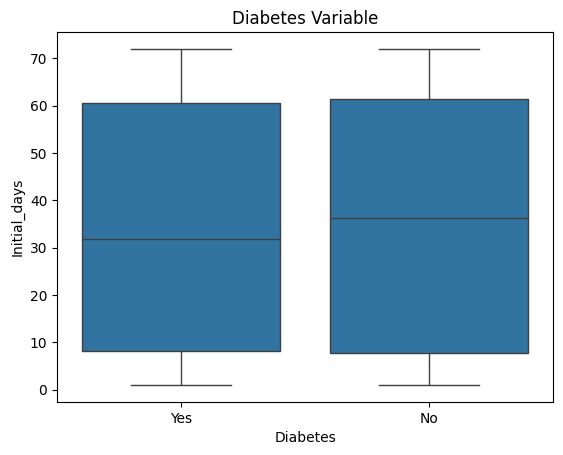

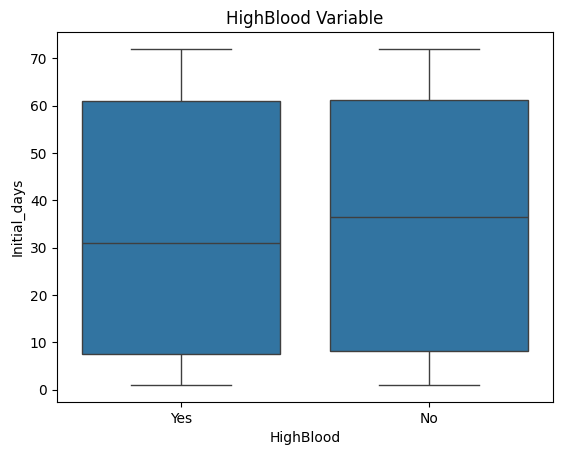

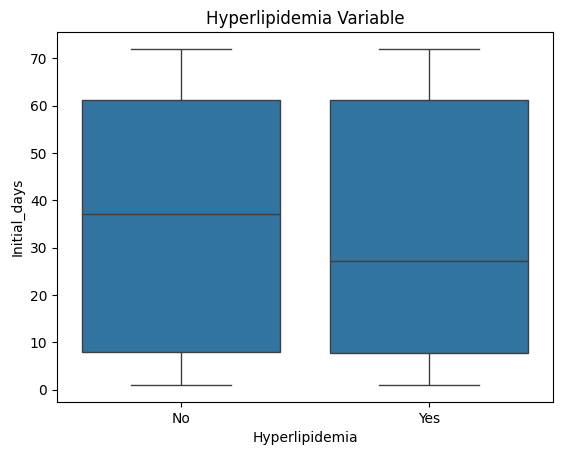

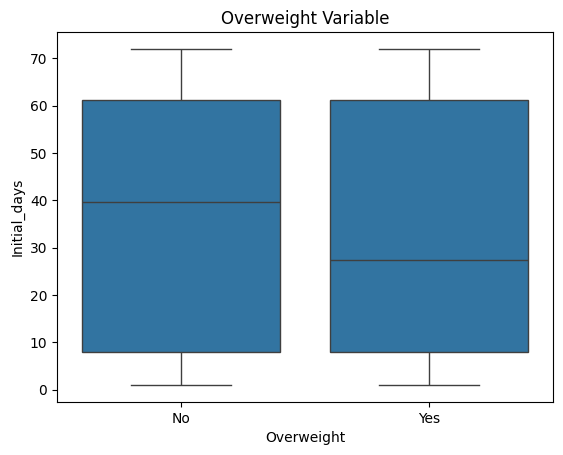

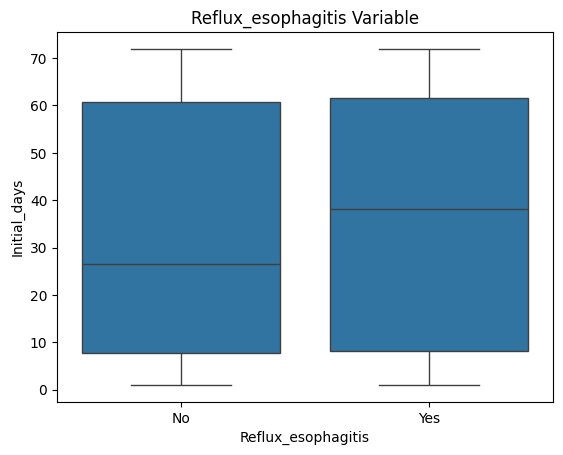

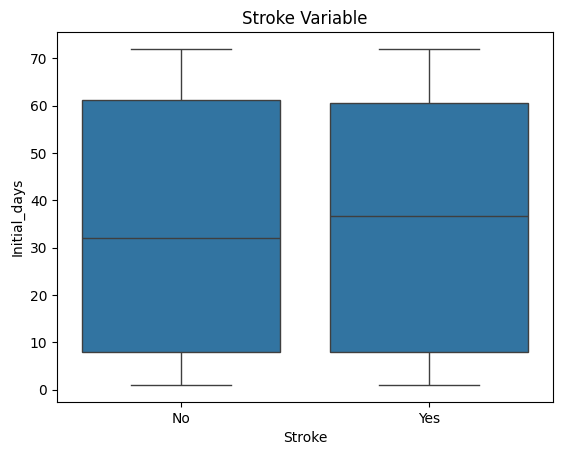

In [ ]:
# Bivariate Analysis (visualization) - all explanatory variables
# Create a loop to plot all explanatory variables on a box plot 
for var in final_list:
    sns.boxplot(x=var, y='Initial_days',data=df_clean)
    plt.title(var+' Variable')
    plt.xlabel(var)
    plt.ylabel('Initial_days')
    # plt.savefig(var+' vs. Initial_days - Boxplot.png',bbox_inches='tight')
    plt.show()

## Data Wrangling
Re-expression of categorical variables

In [ ]:
# convert all categorical variables with binary answers into binary encoding
df_clean = df_clean.replace({'Yes': 1, 'No': 0})

df_clean.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Timely_admission,Timely_treatment,Timely_visits,Reliability,Options,Hrs_of_treatment,Courteous_staff,Active_listening
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,0,19.141466,6,0,0,0,Emergency Admission,1,0,Medium,0,1,1,0,1,1,1,0,1,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,0,18.940352,4,2,1,0,Emergency Admission,1,0,High,1,0,0,0,0,0,0,1,0,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,0,18.057507,4,1,0,0,Elective Admission,1,0,Medium,1,0,1,0,0,0,0,0,0,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,0,16.576858,4,1,0,0,Elective Admission,0,1,Medium,0,1,0,0,0,0,0,1,1,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,0,17.439069,5,0,2,1,Elective Admission,0,0,Low,0,0,0,1,0,0,1,0,0,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# convert binary explanatory variable data types to int types
bin_list = final_list + ['ReAdmis','Soft_drink']

for var in bin_list:
    df_clean[var] = df_clean[var].astype(int)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

# Model Comparison and Analysis

## Initial Model
Create a gross model with all explanatory variables selected. 

Include a y-intercept in your regression model. 

In [ ]:
mdl = ols("Initial_days ~ Allergic_rhinitis + Anxiety + Arthritis + Asthma + BackPain + Diabetes + HighBlood + Hyperlipidemia + Overweight + Reflux_esophagitis + Stroke", data=df_clean).fit()

print(mdl.summary())

                            OLS Regression Results                            
Dep. Variable:           Initial_days   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.203
Date:                Sat, 27 Apr 2024   Prob (F-statistic):              0.279
Time:                        18:59:24   Log-Likelihood:                -46882.
No. Observations:               10000   AIC:                         9.379e+04
Df Residuals:                    9988   BIC:                         9.387e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             34.0894      0

In [ ]:
# Note: Check for multicollinearity after initial model and before the reduced model to not prematurely eliminate too many variables
# Variance Inflaction Factor (VIF)

# the independent variables set 
X = df_clean[['Allergic_rhinitis', 'Anxiety', 'Arthritis', 'Asthma', 'BackPain', 'Diabetes', 'HighBlood', 'Hyperlipidemia', 'Overweight', 'Reflux_esophagitis', 'Stroke']] 
X = add_constant(X)

# VIF dataframe 
vif_data = pd.DataFrame() 
vif_data["Feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 

print(vif_data)

               Feature       VIF
0                const  8.671479
1    Allergic_rhinitis  1.000464
2              Anxiety  1.001024
3            Arthritis  1.001397
4               Asthma  1.001007
5             BackPain  1.001229
6             Diabetes  1.000918
7            HighBlood  1.001164
8       Hyperlipidemia  1.000876
9           Overweight  1.001387
10  Reflux_esophagitis  1.000838
11              Stroke  1.000894


Multicollinearity is present when VIF > 10.
[Note: For this multicollinearity test, a constant was required in the matrix of explanatory variables.]

## Reduced Model
Technique: Variable (Feature) Selection - Recursive Feature Elimination 

Reducing the number of input variables that are now reflecting only correlated variables to your target variable.

In [ ]:
# Feature extraction
X = df_clean[['Allergic_rhinitis', 'Anxiety', 'Arthritis', 'Asthma', 'BackPain', 'Diabetes', 'HighBlood', 'Hyperlipidemia', 'Overweight', 'Reflux_esophagitis', 'Stroke']] 

Y = df_clean['Initial_days']

model = LinearRegression()

rfe = RFE(model)
fit = rfe.fit(X,Y)
print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))
print("Feature Ranking: %s" % (fit.ranking_))

list(np.array(final_list)[fit.support_])

Num Features: 5
Selected Features: [False  True  True  True  True False False False  True False False]
Feature Ranking: [5 1 1 1 1 6 3 4 1 2 7]


['Anxiety', 'Arthritis', 'Asthma', 'BackPain', 'Overweight']

In [ ]:
# create list of selected features 
RFE_list = ['Anxiety', 'Arthritis', 'Asthma','BackPain','Overweight']

# Reduced Model 
mdl_reduced = ols("Initial_days ~ Anxiety + Arthritis + Asthma + BackPain + Overweight", data=df_clean).fit()

print(mdl_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:           Initial_days   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.229
Date:                Sat, 27 Apr 2024   Prob (F-statistic):             0.0486
Time:                        18:59:24   Log-Likelihood:                -46883.
No. Observations:               10000   AIC:                         9.378e+04
Df Residuals:                    9994   BIC:                         9.382e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.1596      0.618     55.276      0.0

## Residual Plots
The smaller the residual standard error, the better the model fits the data set.

Text(0, 0.5, 'Residuals')

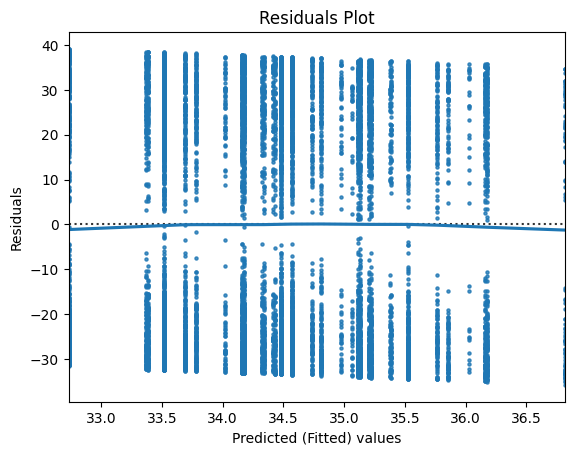

In [ ]:
# Scatterplot of the residuals versus the predicted (fitted) values of Y. 
# Note: residuals are along the Y axis and the predicted (fitted) are along the X axis 
# This is helpful to visually check for the assumption of homoscedasticity.

y_pred = mdl_reduced.predict(X)
residuals = Y - y_pred

sns.residplot(x=y_pred, y=residuals, data=df_clean, lowess=True, scatter_kws={"s":5})
plt.title('Residuals Plot')
plt.xlabel("Predicted (Fitted) values")
plt.ylabel("Residuals")
# plt.savefig('Residuals Plot.png',bbox_inches='tight')

Text(0.5, 1.0, 'Q-Q Plot of Dependent Variable (Initial_days)')

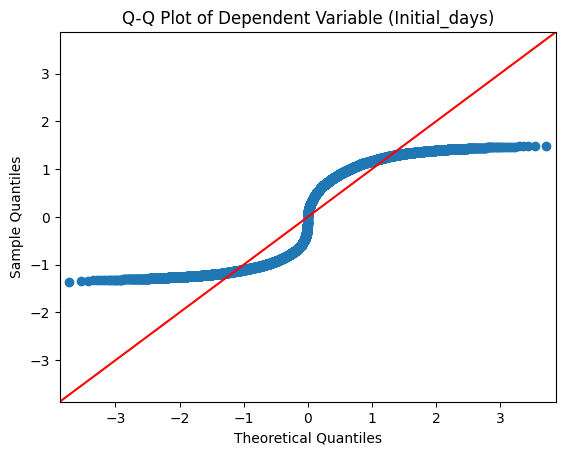

In [ ]:
# Q-Q plot or histogram of the residuals 
# This is helpful to visally check for the assumption normality of residuals.
from statsmodels.api import qqplot
qqplot(data=mdl_reduced.resid, fit=True, line="45")
plt.title('Q-Q Plot of Dependent Variable (Initial_days)') 
# plt.savefig('Q-Q Plot of Dependent Variable (Initial_days).png',bbox_inches='tight')

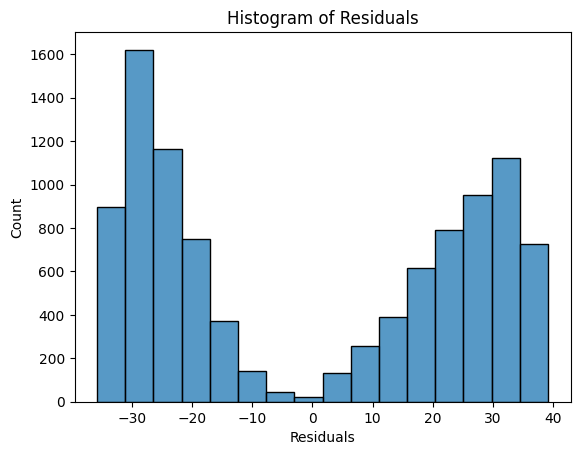

In [ ]:
# histogram of residuals

sns.histplot(residuals)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
# plt.savefig('Histogram of Residuals.png',bbox_inches='tight')
plt.show()

In [ ]:
# Calculate the residual standard error (measures the standard deviation of your residual) 
mse=mdl_reduced.mse_resid
print('mse: ', mse)

rse = np.sqrt(mse)
print("rse: ", rse)

mse:  691.7562044003059
rse:  26.301258608673198


## Summary
•	Since the p-values were greater than 0.05, the study failed to reject the null hypothesis. 

•	The results from the study do not have any practical significance since the adjusted r-squared value is close to zero. 

•	In this study, the multiple linear regression model failed to establish a significant correlation between a patient's length of stay and their medical conditions.



In [ ]:
# save prepared data set
# df_clean.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\4. Linear Regression Modeling in Python\Output\df_clean.csv",index=False)